In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/ghana_district_cases.csv')

print(df.head())
print(df.columns)

     district        region_name  region_code  year_start  year_end  \
0       Bawku  Upper East Region           15        2014      2017   
1  Bawku West  Upper East Region           15        2014      2017   
2     Binduri  Upper East Region           15        2014      2017   
3        Bole    Northern Region           12        2014      2017   
4  Bolgatanga  Upper East Region           15        2014      2017   

   months_reported  suspected_cases  tested_cases  positive_cases  \
0               48          1178349        931717          375349   
1               48           763380        637217          330111   
2               48           349083        309419          195412   
3               48           606409        290958          191586   
4               48          1193785       1093550          589849   

   mean_population  positive_per_100k  net_coverage_pct  
0         109220.3          343662.30             79.56  
1         104485.8          315938.62     

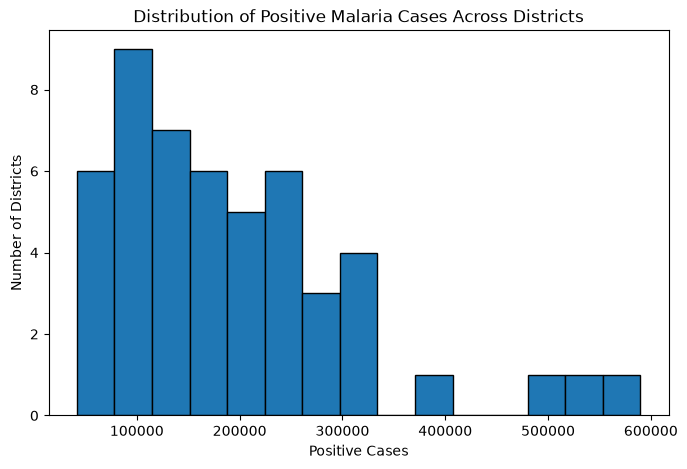

Mean: 195639.62
Variance: 15100003891.51
Variance / Mean ratio: 77182.75


In [19]:
# Look at the case counts
case_counts = df['positive_cases']

# Plot a histogram
plt.figure(figsize=(8, 5))
plt.hist(case_counts, bins=15, edgecolor='black')
plt.xlabel('Positive Cases')
plt.ylabel('Number of Districts')
plt.title('Distribution of Positive Malaria Cases Across Districts')
plt.show()

# Mean vs variance check
mean_cases = case_counts.mean()
var_cases = case_counts.var()

print(f"Mean: {mean_cases:.2f}")
print(f"Variance: {var_cases:.2f}")
print(f"Variance / Mean ratio: {var_cases / mean_cases:.2f}")

In [15]:
print("CASE COUNT:", case_counts.describe())
print(df[['district', 'year_start', 'year_end', 'months_reported']].head(15))
print(df['district'].duplicated().sum())
df.describe()

CASE COUNT: count        50.000000
mean     195639.620000
std      122882.073109
min       41612.000000
25%       98679.750000
50%      158425.000000
75%      242639.750000
max      589849.000000
Name: positive_cases, dtype: float64
                district  year_start  year_end  months_reported
0                  Bawku        2014      2017               48
1             Bawku West        2014      2017               48
2                Binduri        2014      2017               48
3                   Bole        2014      2017               48
4             Bolgatanga        2014      2017               48
5                  Bongo        2014      2017               48
6           Builsa North        2014      2017               48
7           Builsa South        2014      2017               48
8      Bunkpurugu-Yunyoo        2014      2017               48
9          Central Gonja        2014      2017               48
10             Chereponi        2014      2017               48

,region_code,year_start,year_end,months_reported,suspected_cases,tested_cases,positive_cases,mean_population,positive_per_100k,net_coverage_pct,calculated_rate
count,50.000000,50.0,50.0,50.0,5.000000e+01,5.000000e+01,50.000000,50.000000,50.000000,50.000000,50.000000
mean,13.660000,2014.0,2017.0,48.0,4.582221e+05,3.533569e+05,195639.620000,95776.176000,234478.496200,71.231600,234478.473626
std,1.779819,0.0,0.0,0.0,2.525732e+05,2.372498e+05,122882.073109,43447.545786,146156.275949,5.054089,146156.237008
min,12.000000,2014.0,2017.0,48.0,1.427190e+05,6.491900e+04,41612.000000,36585.100000,36994.760000,67.690000,36994.762755
25%,12.000000,2014.0,2017.0,48.0,3.083872e+05,1.748592e+05,98679.750000,62815.775000,106345.185000,67.690000,106345.187324
50%,12.000000,2014.0,2017.0,48.0,3.981325e+05,3.001885e+05,158425.000000,89382.700000,215107.015000,67.690000,215107.061959
75%,15.000000,2014.0,2017.0,48.0,5.737580e+05,4.400000e+05,242639.750000,124155.125000,333494.735000,77.110000,333494.663088
max,16.000000,2014.0,2017.0,48.0,1.193785e+06,1.093550e+06,589849.000000,255649.700000,713356.370000,79.560000,713356.237921


In [7]:
print(df[['district', 'positive_cases', 'mean_population']].sort_values('mean_population').head(5))
print(df[['district', 'positive_cases', 'mean_population']].sort_values('mean_population').tail(5))

correlation = df['positive_cases'].corr(df['mean_population'])
print(f"Correlation between positive_cases and mean_population: {correlation:.3f}")

                district  positive_cases  mean_population
11  Daffiama-Bussie-Issa          154954          36585.1
26                Nabdam          265768          37256.0
7           Builsa South          158164          40623.0
21              Kumbungu           51640          45219.7
46            West Gonja           96371          47943.7
           district  positive_cases  mean_population
12       East Gonja           87768         155946.5
35  Savelugu-Nanton          145932         159170.0
29    Nanumba North          142368         161942.8
34        Sagnarigu           82041         168144.9
40           Tamale           94577         255649.7
Correlation between positive_cases and mean_population: 0.093


In [8]:
# Manually recompute the rate and compare to the provided column
df['calculated_rate'] = (df['positive_cases'] / df['mean_population']) * 100000

print(df[['district', 'positive_cases', 'mean_population', 'positive_per_100k', 'calculated_rate']].head(10))

            district  positive_cases  mean_population  positive_per_100k  \
0              Bawku          375349         109220.3          343662.30   
1         Bawku West          330111         104485.8          315938.62   
2            Binduri          195412          68482.8          285344.82   
3               Bole          191586          70912.2          270173.45   
4         Bolgatanga          589849         146647.9          402221.14   
5              Bongo          332006          94019.1          353126.26   
6       Builsa North          198952          62704.0          317287.67   
7       Builsa South          158164          40623.0          389346.37   
8  Bunkpurugu-Yunyoo          173167         139484.4          124147.94   
9      Central Gonja          158686          99731.5          159113.18   

   calculated_rate  
0    343662.304535  
1    315938.625153  
2    285344.641282  
3    270173.538545  
4    402221.238763  
5    353126.120118  
6    317287.5733

In [11]:
print(df.shape)
print(df['district'].nunique())
print(df[['district', 'positive_cases', 'mean_population', 'positive_per_100k']].to_string())

(50, 13)
50
                district  positive_cases  mean_population  positive_per_100k
0                  Bawku          375349         109220.3          343662.30
1             Bawku West          330111         104485.8          315938.62
2                Binduri          195412          68482.8          285344.82
3                   Bole          191586          70912.2          270173.45
4             Bolgatanga          589849         146647.9          402221.14
5                  Bongo          332006          94019.1          353126.26
6           Builsa North          198952          62704.0          317287.67
7           Builsa South          158164          40623.0          389346.37
8      Bunkpurugu-Yunyoo          173167         139484.4          124147.94
9          Central Gonja          158686          99731.5          159113.18
10             Chereponi           93652          62151.1          150684.39
11  Daffiama-Bussie-Issa          154954          36585.1       

A1. Positive case counts are highly right-skewed, ranging from 158164 to 589849 across 50 districts (mean = 195,640, variance/mean ratio ≈ 77,183), indicating strong over-dispersion. Note: positive_cases is a cumulative count over 2014–2017 (per the data dictionary), so high per-capita values reflect repeat testing/reinfection over four years rather than unique individuals affected.

Fitted λ (lambda): 195639.62


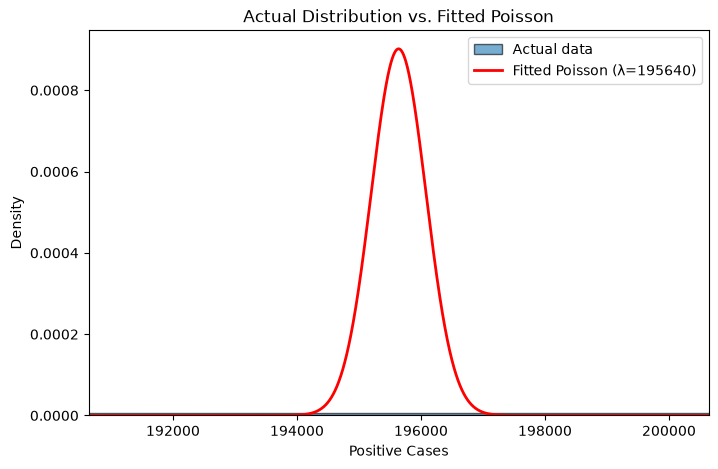

In [13]:
#start of A2
from scipy import stats
import numpy as np

# The Poisson MLE is simply the sample mean — no calculus needed here
lambda_hat = case_counts.mean()
print(f"Fitted λ (lambda): {lambda_hat:.2f}")

# Generate x-values across the same range as our real data, for plotting the fitted curve
x_values = np.arange(case_counts.min(), case_counts.max())

# Poisson probability mass function at each x, given our fitted lambda
poisson_pmf = stats.poisson.pmf(x_values, lambda_hat)

# Overlay: real histogram (density-normalized) vs. fitted Poisson curve
plt.figure(figsize=(8, 5))
plt.hist(case_counts, bins=30, density=True, edgecolor='black', alpha=0.6, label='Actual data')
plt.plot(x_values, poisson_pmf, 'r-', linewidth=2, label=f'Fitted Poisson (λ={lambda_hat:.0f})')
plt.xlabel('Positive Cases')
plt.ylabel('Density')
plt.title('Actual Distribution vs. Fitted Poisson')

plt.xlim(lambda_hat - 5000, lambda_hat + 5000)  # zoom in tightly around the mean

plt.legend()
plt.show()

A2. Fitting a Poisson model (λ = mean = 195,640) and overlaying it against the actual data confirms a dramatic mismatch. Poisson's implied spread (√λ ≈ 442) is minuscule compared to the true range of case counts (~41,600–590,000, a range over 1,000× wider than Poisson predicts). Even zoomed to a narrow window around λ, the fitted Poisson forms a steep, narrow peak, while actual districts are sparse in that region — visual confirmation that a single-parameter Poisson cannot capture the true variability across districts. This motivates moving to a Negative Binomial model (A3), which allows variance to exceed the mean.

In [ ]:
import statsmodels.api as sm

# NB needs a design matrix for the mean - here we use just an intercept (no covariates yet),
# matching what we did with Poisson (single overall rate)
X = np.ones(len(case_counts))  # a column of 1s = "intercept only" model

nb_model = sm.NegativeBinomial(case_counts, X).fit()
print(nb_model.summary())

Optimization terminated successfully.
         Current function value: 12.942009
         Iterations: 6
         Function evaluations: 7
         Gradient evaluations: 7
                     NegativeBinomial Regression Results                      
Dep. Variable:         positive_cases   No. Observations:                   50
Model:               NegativeBinomial   Df Residuals:                       49
Method:                           MLE   Df Model:                            0
Date:                Fri, 18 Sep 2026   Pseudo R-squ.:              -2.528e-12
Time:                        10:11:19   Log-Likelihood:                -647.10
converged:                       True   LL-Null:                       -647.10
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.1840      0.083    147.

// A3 start

alpha = 0.3416 — this is the over-dispersion parameter. It's greater than 0, confirming NB found real over-dispersion (if alpha were ~0, NB would essentially collapse back into Poisson). This is the number you quote: "NB found alpha ≈ 0.34, confirming significant over-dispersion beyond what Poisson allows."

In [16]:
nb_mean = np.exp(12.1840)
print(f"NB fitted mean: {nb_mean:.2f}")
print(f"Actual data mean: {case_counts.mean():.2f}")

NB fitted mean: 195633.83
Actual data mean: 195639.62


These two numbers should match almost exactly — NB's mean estimate should equal the data's mean, same as Poisson did. The difference isn't in the mean; it's in how each model treats the spread around that mean. That's your basic comparison sentence for the notebook.

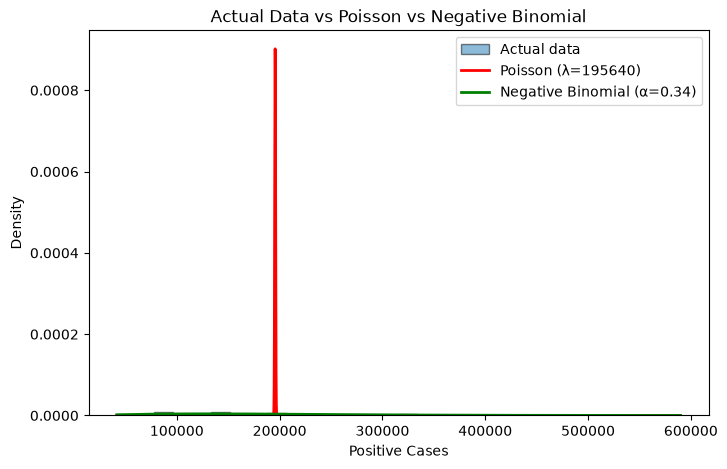

In [17]:
from scipy import stats

x_values = np.arange(case_counts.min(), case_counts.max())

# Poisson pmf (already have lambda_hat from A2)
poisson_pmf = stats.poisson.pmf(x_values, lambda_hat)

# NB pmf: scipy parameterizes NB differently (n, p) instead of (mean, alpha)
# Convert: n = 1/alpha, p = n / (n + mean)
alpha_hat = 0.3416
n_param = 1 / alpha_hat
p_param = n_param / (n_param + nb_mean)
nb_pmf = stats.nbinom.pmf(x_values, n_param, p_param)

plt.figure(figsize=(8, 5))
plt.hist(case_counts, bins=30, density=True, edgecolor='black', alpha=0.5, label='Actual data')
plt.plot(x_values, poisson_pmf, 'r-', linewidth=2, label=f'Poisson (λ={lambda_hat:.0f})')
plt.plot(x_values, nb_pmf, 'g-', linewidth=2, label=f'Negative Binomial (α={alpha_hat:.2f})')
plt.xlabel('Positive Cases')
plt.ylabel('Density')
plt.title('Actual Data vs Poisson vs Negative Binomial')
plt.legend()
plt.show()

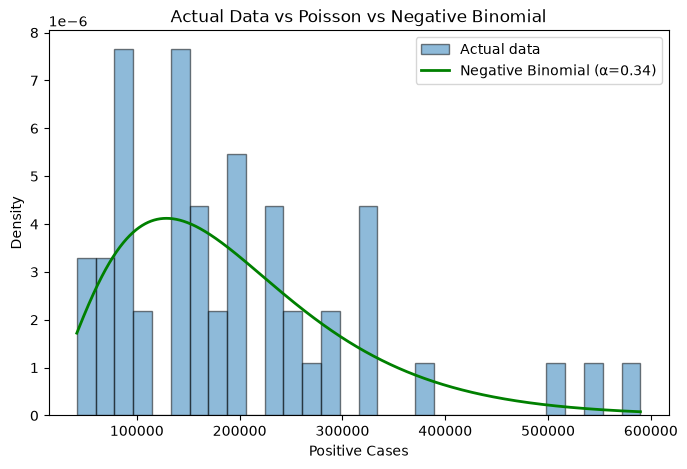

In [18]:
from scipy import stats

x_values = np.arange(case_counts.min(), case_counts.max())

# Poisson pmf (already have lambda_hat from A2)
poisson_pmf = stats.poisson.pmf(x_values, lambda_hat)

# NB pmf: scipy parameterizes NB differently (n, p) instead of (mean, alpha)
# Convert: n = 1/alpha, p = n / (n + mean)
alpha_hat = 0.3416
n_param = 1 / alpha_hat
p_param = n_param / (n_param + nb_mean)
nb_pmf = stats.nbinom.pmf(x_values, n_param, p_param)

plt.figure(figsize=(8, 5))
plt.hist(case_counts, bins=30, density=True, edgecolor='black', alpha=0.5, label='Actual data')
# plt.plot(x_values, poisson_pmf, 'r-', linewidth=2, label=f'Poisson (λ={lambda_hat:.0f})')
plt.plot(x_values, nb_pmf, 'g-', linewidth=2, label=f'Negative Binomial (α={alpha_hat:.2f})')
plt.xlabel('Positive Cases')
plt.ylabel('Density')
plt.title('Actual Data vs Poisson vs Negative Binomial')
plt.legend()
plt.show()